##SHAP Analysis Globally

Rows : 144233
Cols : 492


Saving fraud_model.sav to fraud_model (1).sav
Loaded model: fraud_model (1).sav
Calculating SHAP values...
Done!

1. SUMMARY PLOT


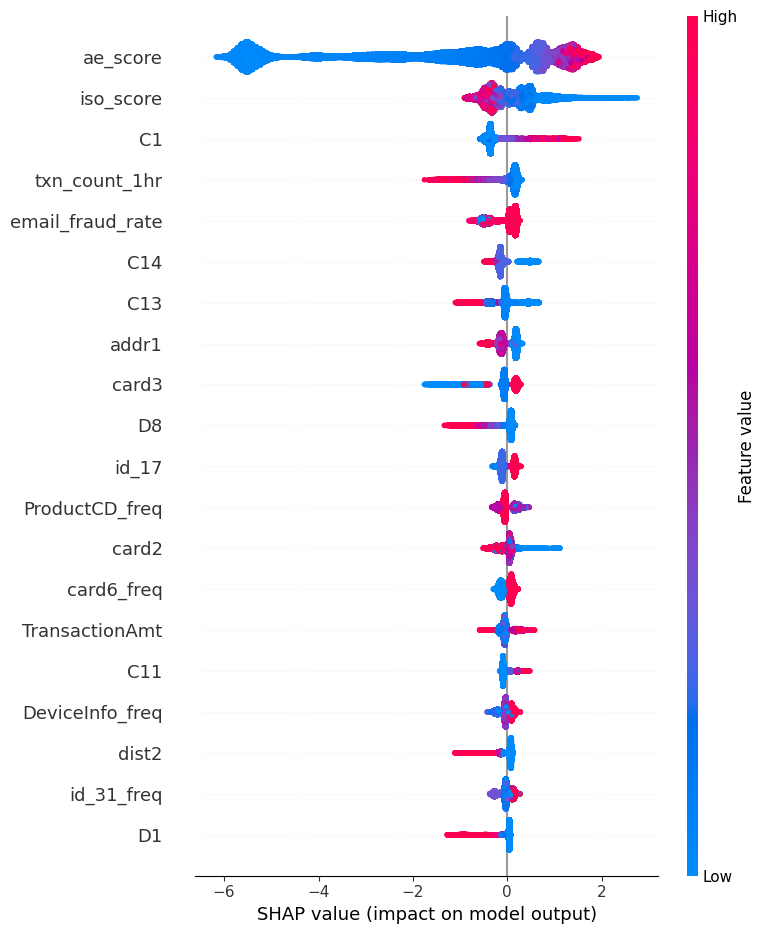


2. BAR PLOT


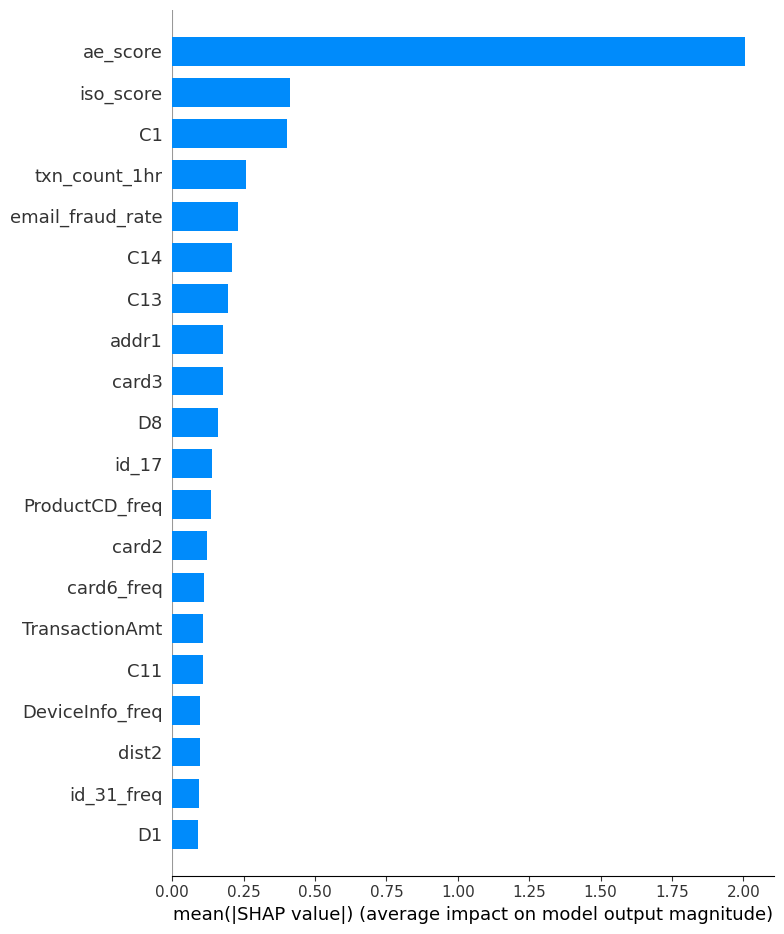


3. DEPENDENCE PLOT
Top feature selected: ae_score


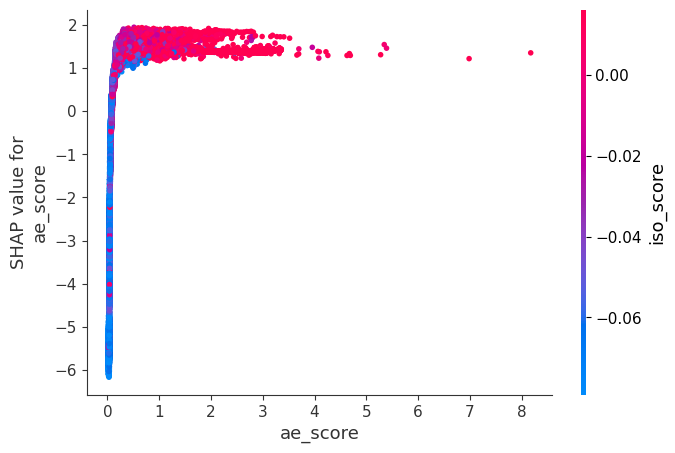


4. FEATURE INTERACTION PLOT
Using: ae_score and iso_score


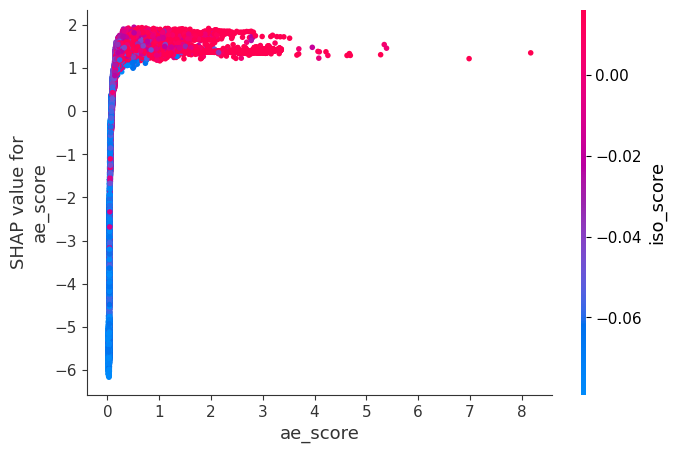


Top 20 Fraud Driving Features:
              Feature  MeanAbsSHAP
489          ae_score     2.006904
491         iso_score     0.410368
24                 C1     0.401456
348     txn_count_1hr     0.258619
345  email_fraud_rate     0.229252
35                C14     0.208481
34                C13     0.194752
21              addr1     0.176756
19              card3     0.176641
41                 D8     0.159559
11              id_17     0.137571
483    ProductCD_freq     0.135907
18              card2     0.122249
485        card6_freq     0.111151
16     TransactionAmt     0.106676
32                C11     0.105829
482   DeviceInfo_freq     0.097672
23              dist2     0.097611
474        id_31_freq     0.094163
36                 D1     0.088960

Saved: shap_feature_importance.csv


In [ ]:
!pip install shap xgboost pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv("/content/final_dataset_after_feature_selection_in_xgboost.csv")

# ----------------------------------------------------------
# 2. DEFINE FEATURES / TARGET
# ----------------------------------------------------------
TARGET = "isFraud"

DROP_COLS = []
if "TransactionDT" in df.columns:
    DROP_COLS.append("TransactionDT")

FEATURES = [c for c in df.columns if c not in [TARGET] + DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

print("Rows :", X.shape[0])
print("Cols :", X.shape[1])

# ----------------------------------------------------------
# 3. UPLOAD MODEL (.sav)
# ----------------------------------------------------------
from google.colab import files
uploaded = files.upload()

# Example file: fraud_model.sav
model_file = list(uploaded.keys())[0]

model = joblib.load(model_file)

print("Loaded model:", model_file)

# ----------------------------------------------------------
# 4. CREATE SHAP EXPLAINER
# ----------------------------------------------------------
explainer = shap.TreeExplainer(model)



X_used = X.copy()

print("Calculating SHAP values...")

shap_values = explainer.shap_values(X_used)

# If binary classifier output shape issue
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("Done!")

# ==========================================================
# VISUALIZATION 1 : SUMMARY PLOT (MOST IMPORTANT)
# ==========================================================
print("\n1. SUMMARY PLOT")
shap.summary_plot(shap_values, X_used, max_display=20)

# ==========================================================
# VISUALIZATION 2 : BAR PLOT
# Mean Absolute SHAP Values
# ==========================================================
print("\n2. BAR PLOT")
shap.summary_plot(
    shap_values,
    X_used,
    plot_type="bar",
    max_display=20
)

# ==========================================================
# VISUALIZATION 3 : DEPENDENCE PLOT
# Top feature automatically selected
# ==========================================================
print("\n3. DEPENDENCE PLOT")

mean_abs = np.abs(shap_values).mean(axis=0)
top_feature = X_used.columns[np.argmax(mean_abs)]

print("Top feature selected:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_used
)

# ==========================================================
# VISUALIZATION 4 : FEATURE INTERACTION PLOT
# Top 2 features
# ==========================================================
print("\n4. FEATURE INTERACTION PLOT")

top2_idx = np.argsort(mean_abs)[::-1][:2]
f1 = X_used.columns[top2_idx[0]]
f2 = X_used.columns[top2_idx[1]]

print("Using:", f1, "and", f2)

shap.dependence_plot(
    f1,
    shap_values,
    X_used,
    interaction_index=f2
)

# ==========================================================
# EXTRA TABLE : TOP FEATURES
# ==========================================================
importance = pd.DataFrame({
    "Feature": X_used.columns,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

print("\nTop 20 Fraud Driving Features:")
print(importance.head(20))

# ==========================================================
# OPTIONAL SAVE CSV
# ==========================================================
importance.to_csv("shap_feature_importance.csv", index=False)

print("\nSaved: shap_feature_importance.csv")

##SHAP Local Analysis

Saving fraud_model.sav to fraud_model.sav
Loaded Model: fraud_model.sav

FRAUD CASE EXPLANATION
Actual Label     : 1
Predicted Label  : 1
Fraud Probability: 0.9954

Top 5 Reasons:
      Feature    Impact
489  ae_score  1.777352
24         C1  0.738328
155      V152  0.448915
34        C13  0.344280
35        C14  0.325824

Conclusion:
This transaction is termed FRAUD because these features increased fraud score:
['ae_score', 'C1', 'V152']

WATERFALL PLOT


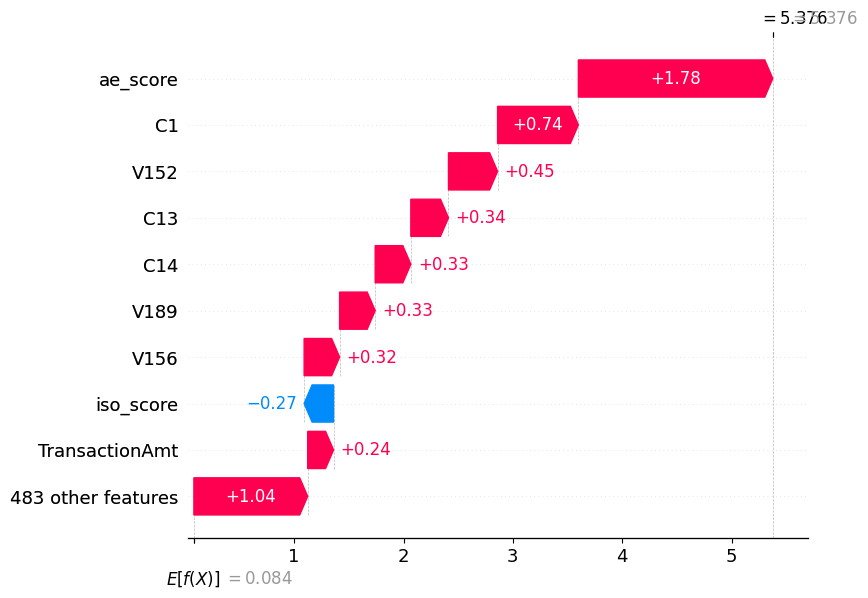


FORCE PLOT



NON FRAUD CASE EXPLANATION
Actual Label     : 0
Predicted Label  : 0
Fraud Probability: 0.1264

Top 5 Reasons:
      Feature    Impact
489  ae_score  1.114534
36         D1 -0.919842
24         C1 -0.456089
37         D4 -0.311059
34        C13 -0.306688

Conclusion:
This transaction is termed NON-FRAUD because these features reduced fraud score:
['D1', 'C1', 'D4']

WATERFALL PLOT


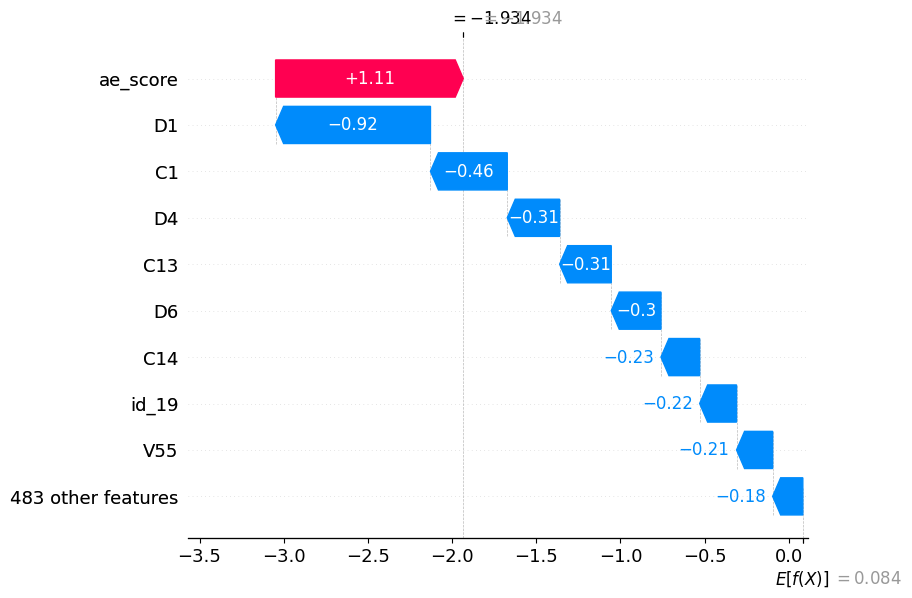


FORCE PLOT



DECISION PLOT (Fraud vs Non Fraud)


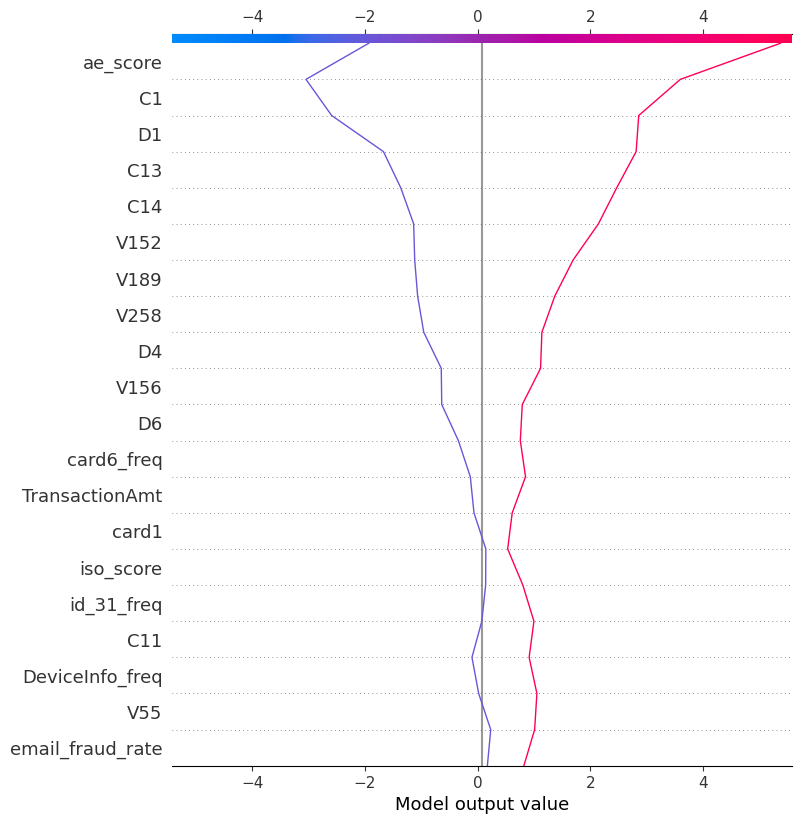

In [ ]:
# ==========================================================
# LOCAL SHAP EXPLAINABILITY
# 1 FRAUD + 1 NON FRAUD CASE
# Waterfall / Force / Decision Plot
# ==========================================================

!pip install shap pandas numpy matplotlib joblib -q

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv("/content/final_dataset_after_feature_selection_in_xgboost.csv")

# ----------------------------------------------------------
# 2. FEATURES
# ----------------------------------------------------------
TARGET = "isFraud"

DROP_COLS = []
if "TransactionDT" in df.columns:
    DROP_COLS.append("TransactionDT")

FEATURES = [c for c in df.columns if c not in [TARGET] + DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

# ----------------------------------------------------------
# 3. PICK ONE FRAUD + ONE NON FRAUD
# ----------------------------------------------------------
fraud_case = df[df["isFraud"] == 1].sample(1, random_state=42)
safe_case  = df[df["isFraud"] == 0].sample(1, random_state=42)

# ----------------------------------------------------------
# 4. UPLOAD MODEL (.sav)
# ----------------------------------------------------------
from google.colab import files
uploaded = files.upload()

model_file = list(uploaded.keys())[0]
model = joblib.load(model_file)

print("Loaded Model:", model_file)

# ----------------------------------------------------------
# 5. SHAP EXPLAINER
# ----------------------------------------------------------
explainer = shap.TreeExplainer(model)

# ==========================================================
# FUNCTION TO EXPLAIN SINGLE CASE
# ==========================================================
def explain_case(case_df, title):

    row = case_df[FEATURES]
    actual = int(case_df["isFraud"].values[0])

    pred_prob = model.predict_proba(row)[0][1]
    pred = int(model.predict(row)[0])

    shap_values = explainer.shap_values(row)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    vals = shap_values[0]

    print("\n================================================")
    print(title)
    print("================================================")
    print("Actual Label     :", actual)
    print("Predicted Label  :", pred)
    print("Fraud Probability:", round(pred_prob,4))

    # --------------------------------------------------
    # TOP REASONS
    # --------------------------------------------------
    impact_df = pd.DataFrame({
        "Feature": FEATURES,
        "Impact": vals
    })

    impact_df["AbsImpact"] = impact_df["Impact"].abs()
    impact_df = impact_df.sort_values("AbsImpact", ascending=False)

    print("\nTop 5 Reasons:")
    print(impact_df[["Feature","Impact"]].head(5))

    # --------------------------------------------------
    # CONCLUSION
    # --------------------------------------------------
    positive = impact_df[impact_df["Impact"] > 0].head(3)
    negative = impact_df[impact_df["Impact"] < 0].head(3)

    if pred == 1:
        print("\nConclusion:")
        print("This transaction is termed FRAUD because these features increased fraud score:")
        print(list(positive["Feature"].values))
    else:
        print("\nConclusion:")
        print("This transaction is termed NON-FRAUD because these features reduced fraud score:")
        print(list(negative["Feature"].values))

    # ==================================================
    # WATERFALL PLOT
    # ==================================================
    print("\nWATERFALL PLOT")
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        vals,
        feature_names=FEATURES
    )

    # ==================================================
    # FORCE PLOT
    # ==================================================
    print("\nFORCE PLOT")
    shap.initjs()

    display(
        shap.force_plot(
            explainer.expected_value,
            vals,
            row,
            matplotlib=False
        )
    )

# ==========================================================
# RUN FRAUD CASE
# ==========================================================
explain_case(fraud_case, "FRAUD CASE EXPLANATION")

# ==========================================================
# RUN NON FRAUD CASE
# ==========================================================
explain_case(safe_case, "NON FRAUD CASE EXPLANATION")

# ==========================================================
# DECISION PLOT (Both Cases Together)
# ==========================================================
print("\n================================================")
print("DECISION PLOT (Fraud vs Non Fraud)")
print("================================================")

combined = pd.concat([
    fraud_case[FEATURES],
    safe_case[FEATURES]
])

shap_values = explainer.shap_values(combined)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.decision_plot(
    explainer.expected_value,
    shap_values,
    combined,
    feature_names=FEATURES
)